<h2>BTC Price Data Connection</h2>

How can we get hold of BTC price data, both live **and** historical?

In [1]:
import sys
from pathlib import Path
import pickle
import numpy as np
import pandas as pd

In [2]:
PROJ_ROOT = Path().resolve().parents[0]
project_root = str(PROJ_ROOT)
sys.path.insert(0, project_root)
print(project_root)

/Users/cameroncochrane/Data Projects/vlXsnPPgKKnWqEJB


<h3>yfinance

Only really need the basic daily historical data, and the 'live' price.

In [3]:
import yfinance as yf

In [4]:
btc_data = yf.download('BTC-USD', period='1y', interval='1d')
print(type(btc_data))
btc_data.head()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.DataFrame'>


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-10-02,120681.257812,121086.406250,118383.156250,118652.382812,71415163912
2025-10-03,122266.531250,123944.703125,119344.312500,120656.984375,83941392228
2025-10-04,122425.429688,122857.640625,121577.570312,122267.468750,36769171735
2025-10-05,123513.476562,125559.210938,122191.960938,122419.671875,73689317763
2025-10-06,124752.531250,126198.070312,123196.046875,123510.453125,72568881188


In [5]:
btc_data.tail(5)

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-09-28,83502.609375,84972.664062,82570.718750,84454.117188,42589028679
2026-09-29,83622.429688,84511.281250,82739.093750,83500.320312,28029782264
2026-09-30,83553.851562,85599.804688,82927.875000,83621.398438,36290317874
2026-10-01,84853.101562,85224.273438,83132.757812,83554.250000,32802609098
2026-10-02,86545.992188,86818.039062,84555.460938,84849.929688,40108093440


Restructure the multi-index dataframe into a single index dataframe:

In [6]:
btc_data.columns = btc_data.columns.get_level_values(0)
btc_data = btc_data.reset_index()
print(f"DataFrame memory usage: {btc_data.memory_usage(deep=True).sum() / 1024**2:.2f} MiB")
btc_data.head()

DataFrame memory usage: 0.02 MiB


Price,Date,Close,High,Low,Open,Volume
0,2025-10-02,120681.257812,121086.406250,118383.156250,118652.382812,71415163912
1,2025-10-03,122266.531250,123944.703125,119344.312500,120656.984375,83941392228
2,2025-10-04,122425.429688,122857.640625,121577.570312,122267.468750,36769171735
3,2025-10-05,123513.476562,125559.210938,122191.960938,122419.671875,73689317763
4,2025-10-06,124752.531250,126198.070312,123196.046875,123510.453125,72568881188


This format of data can be the 'raw' data. The processed version will look different for different ML models. For now let's decide how far back we want the raw data to go, then create a function that can be used to download the data and/or refresh existing raw data. We also need a function that collects the current 'live' price for portfolio monitoring/reporting purposes.

In [7]:
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

print(f"DATA_DIR = {DATA_DIR}")
print(f"RAW_DATA_DIR = {RAW_DATA_DIR}")

DATA_DIR = /Users/cameroncochrane/Data Projects/vlXsnPPgKKnWqEJB/data
RAW_DATA_DIR = /Users/cameroncochrane/Data Projects/vlXsnPPgKKnWqEJB/data/raw


Yahoo Finance began tracking and recording daily BTC data on September 17, 2014. This is therefore the maximum historical lookback period (~12 years of data) to train on. Binance is only on August 17, 2017, according to Google.

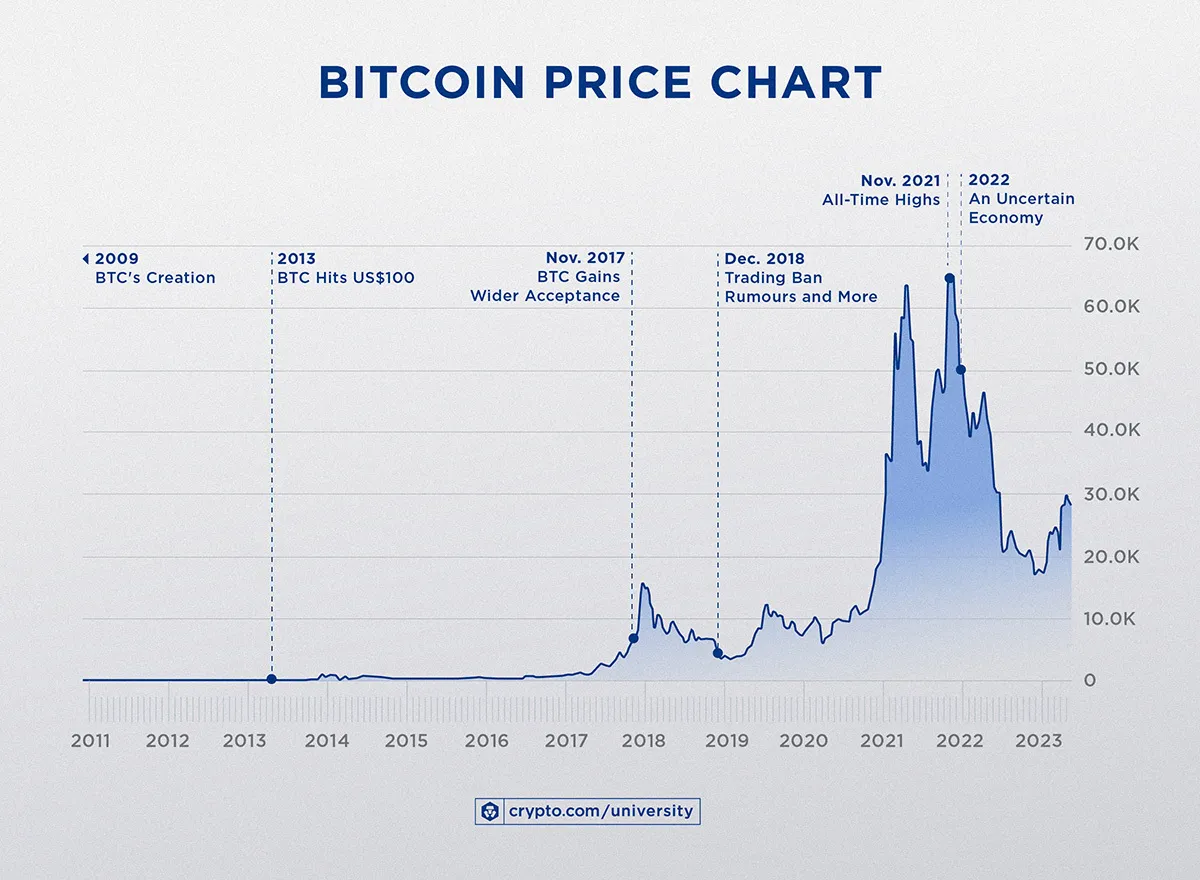

Furthermore, intraday BTC trading is likely futile. Any price fluctuation is just noise when intraday. **The minimum interval will be 1 day.**

*Historical price fetch function:*

- In this context 'raw' means raw training/test data for ML purposes, not the raw output from the yfinance API.

In [8]:
def fetch_historical_BTCUSD(period: str = "max", save_pkl: bool = True, save_path: str | Path = RAW_DATA_DIR / "btc_usd.pkl") -> pd.DataFrame:
    """Download daily BTC-USD history and optionally save it as a pickle.

    Downloads data from Yahoo Finance, flattens multi-index columns if needed,
    and returns a DataFrame with a date column and price columns.

    Args:
        period: Yahoo Finance lookback period, such as ``"1y"`` or ``"max"``.
        save_pkl: Whether to save the downloaded DataFrame.
        save_path: Destination path used when ``save_pkl`` is true.

    Returns:
        The downloaded BTC-USD history as a DataFrame.

    Raises:
        RuntimeError: If Yahoo Finance returns no historical data.

    Examples:
        Download and save the maximum available history:
        ``history = fetch_historical_BTCUSD()``

        Download one year of history without saving:
        ``recent_history = fetch_historical_BTCUSD(period="1y", save_pkl=False)``
    """
    data = yf.download("BTC-USD", period=period, interval="1d")

    if data.empty:
        raise RuntimeError("Yahoo Finance returned no BTC-USD historical data.")

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.reset_index()
    print(f"DataFrame memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MiB")

    if save_pkl:
        path = Path(save_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        data.to_pickle(path)
        print(f"Saved data to {path}")

    return data

TEST_DATA_FILENAME = "btcusd_test_1.pkl"
RAW_DATA_TEST_PATH = RAW_DATA_DIR / TEST_DATA_FILENAME

print(f"RAW_DATA_TEST_PATH = {RAW_DATA_TEST_PATH}")

complete_btc_raw = fetch_historical_BTCUSD(period='max',save_pkl=True,save_path=RAW_DATA_TEST_PATH)
print(complete_btc_raw.shape)

RAW_DATA_TEST_PATH = /Users/cameroncochrane/Data Projects/vlXsnPPgKKnWqEJB/data/raw/btcusd_test_1.pkl


[*********************100%***********************]  1 of 1 completed

DataFrame memory usage: 0.20 MiB
Saved data to /Users/cameroncochrane/Data Projects/vlXsnPPgKKnWqEJB/data/raw/btcusd_test_1.pkl
(4399, 6)


In [9]:
complete_btc_raw.head(10)

Price,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
5,2014-09-22,402.152008,406.915985,397.130005,399.100006,24127600
6,2014-09-23,435.790985,441.557007,396.196991,402.092010,45099500
7,2014-09-24,423.204987,436.112000,421.131989,435.751007,30627700
8,2014-09-25,411.574005,423.519989,409.467987,423.156006,26814400
9,2014-09-26,404.424988,414.937988,400.009003,411.428986,21460800


In [10]:
complete_btc_raw.tail(10)

Price,Date,Close,High,Low,Open,Volume
4389,2026-09-23,84383.007812,87265.492188,83519.734375,86176.765625,46088463341
4390,2026-09-24,84379.062500,84876.226562,82906.617188,84381.593750,37106744985
4391,2026-09-25,84034.921875,85230.054688,83165.531250,84379.515625,34118533914
4392,2026-09-26,84406.453125,84423.179688,83781.109375,84035.820312,15169336375
4393,2026-09-27,84458.085938,85126.109375,84121.328125,84412.718750,19386591468
4394,2026-09-28,83502.609375,84972.664062,82570.718750,84454.117188,42589028679
4395,2026-09-29,83622.429688,84511.281250,82739.093750,83500.320312,28029782264
4396,2026-09-30,83553.851562,85599.804688,82927.875000,83621.398438,36290317874
4397,2026-10-01,84853.101562,85224.273438,83132.757812,83554.250000,32802609098
4398,2026-10-02,86545.992188,86818.039062,84555.460938,84849.929688,40108093440


*Live price fetch function:*

In [11]:
def fetch_live_BTCUSD() -> pd.DataFrame:
    """Fetch the latest available BTC-USD quote or intraday bar from Yahoo Finance.

    Returns one row with ``Date``, ``Close``, ``High``, ``Low``, ``Open``, and
    ``Volume`` columns. If the fast quote is unavailable, the latest 1-minute
    bar is used; that bar may not be current.

    Example:
        ``live_btc = fetch_live_BTCUSD()``
    """
    ticker = yf.Ticker("BTC-USD")

    try:
        quote = ticker.fast_info
        price = quote.get("last_price")
    except Exception:
        quote = {}
        price = None

    bar = None
    if price is None or pd.isna(price):
        intraday = ticker.history(period="1d", interval="1m")
        if not intraday.empty:
            bar = intraday.iloc[-1]
            price = bar.get("Close")

    if price is None or pd.isna(price):
        raise RuntimeError(
            "Yahoo Finance returned no BTC-USD quote or intraday price. Try again later."
        )

    def quote_or_bar(key: str, quote_key: str) -> float:
        value = quote.get(quote_key, np.nan)
        if value is None or pd.isna(value):
            value = bar.get(key, np.nan) if bar is not None else np.nan
        return value

    return pd.DataFrame([{
        "Date": pd.Timestamp.now(tz="UTC").normalize().tz_localize(None),
        "Close": price,
        "High": quote_or_bar("High", "day_high"),
        "Low": quote_or_bar("Low", "day_low"),
        "Open": quote_or_bar("Open", "open"),
        "Volume": quote_or_bar("Volume", "last_volume"),
    }])


current_btc = fetch_live_BTCUSD()
current_btc.head()

,Date,Close,High,Low,Open,Volume
0,2026-10-02,86545.992188,86545.992188,86545.992188,84849.929688,0.0


Generate and save the 'raw' dataset to be used for model training/validation/testing

In [12]:
FINAL_DATA_FILENAME = "btcusd_data.pkl"
RAW_FINAL_DATA_PATH = RAW_DATA_DIR / FINAL_DATA_FILENAME

In [13]:
final_data = fetch_historical_BTCUSD(period='max',save_pkl=True, save_path=RAW_FINAL_DATA_PATH)

[*********************100%***********************]  1 of 1 completed

DataFrame memory usage: 0.20 MiB
Saved data to /Users/cameroncochrane/Data Projects/vlXsnPPgKKnWqEJB/data/raw/btcusd_data.pkl
